In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
module_path = os.path.abspath(os.path.join('../../../../../'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [3]:
from machines.predictions.svr_prediction import SVR_Prediction
from machines.enums import SvrKernelEnum
from preprocesses.preprocess import Preprocess
from preprocesses.enums import TransformEnum, TypeFileEnum, StandardScaleEnum
from metrics.error_metric import ErrorMetric
from metrics.enums import MetricEnum, PlotLegends

Read the file and prepare data for SVR

In [4]:
file_csv = '../../../../../../data/phen/original/obregon_phenotypic_original_151617.csv'
print(os.getcwd())
svr = SVR_Prediction(kernel=SvrKernelEnum.POLY)
preprocessing =  Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.PCA,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

/phen/app/notebooks/phen/pca/phenotypic/svr


Launched SVR

In [5]:
x_train, y_train = preprocessing.get_train()
svr.training(x_train=x_train, y_train=y_train)

In [6]:
x_test, y_test = preprocessing.get_test()
y_predicted = svr.prediction(x_test=x_test)

Get metrics

In [7]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 96.85965823674546
R2 -> 0.025973533511129077
MAPE -> 0.1364256830055229


{'d2_absolute_error_score': 0.02128546901104278,
 'd2_pinball_score': 0.02128546901104278,
 'd2_tweedie_score': 0.025973533511129077,
 'explained_variance_score': 0.10827078071836027,
 'max_error': 371.73409149704275,
 'mean_absolute_error': 68.29225913772439,
 'mean_absolute_percentage_error': 0.1364256830055229,
 'mean_gamma_deviance': 0.030334417734274186,
 'mean_poisson_deviance': 16.620558360182997,
 'mean_squared_error': 9381.793393739134,
 'mean_squared_log_error': 0.03503913612686753,
 'median_absolute_error': 44.735687205256454,
 'r2_score': 0.025973533511129077,
 'root_mean_squared_error': 96.85965823674546,
 'root_mean_squared_log_error': 0.18718743581466019}

Plots:

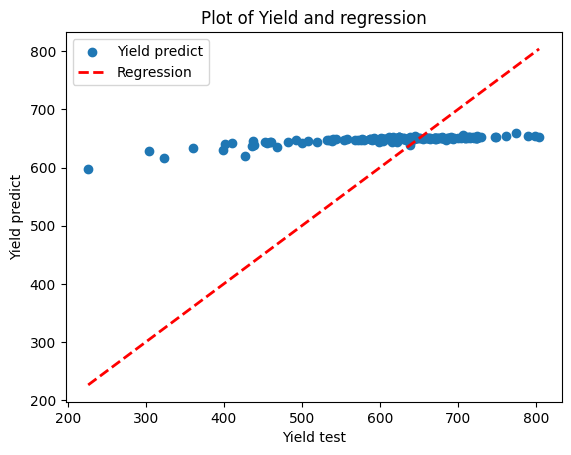

In [8]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = "Plot of Yield and regression"
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)


Plot $r^2$

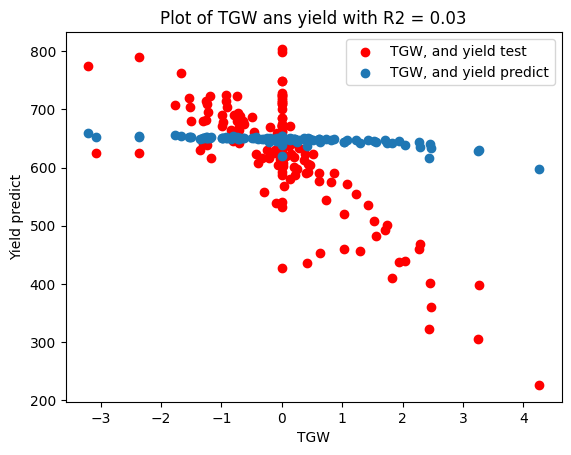

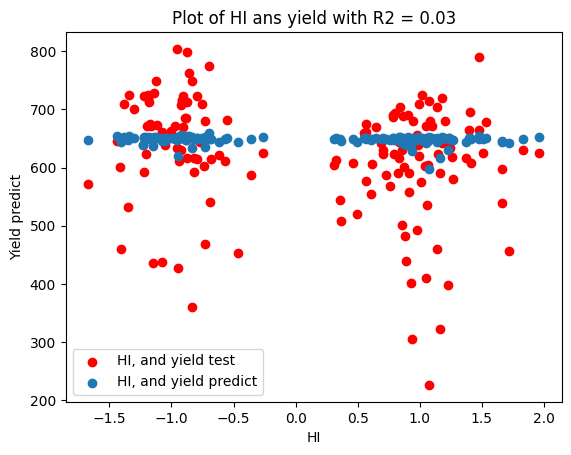

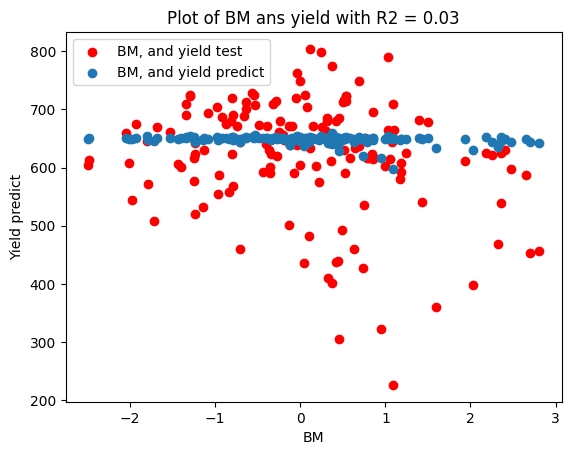

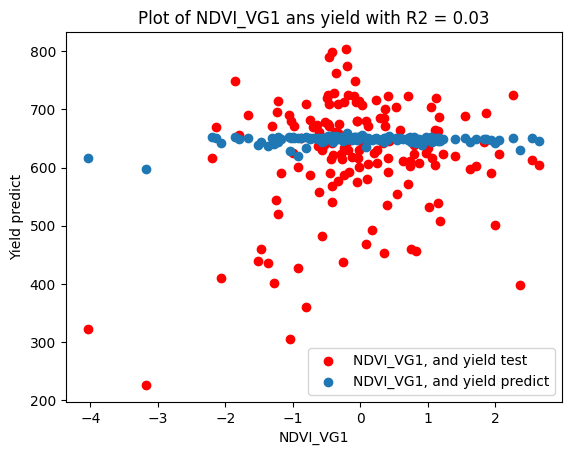

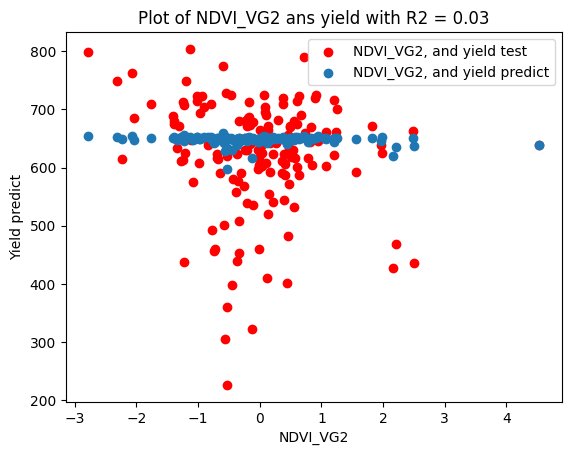

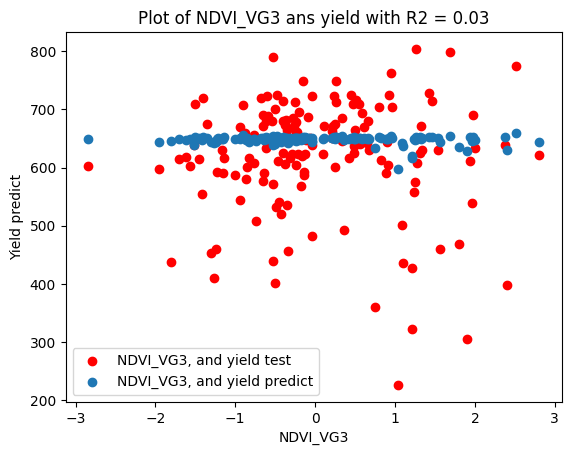

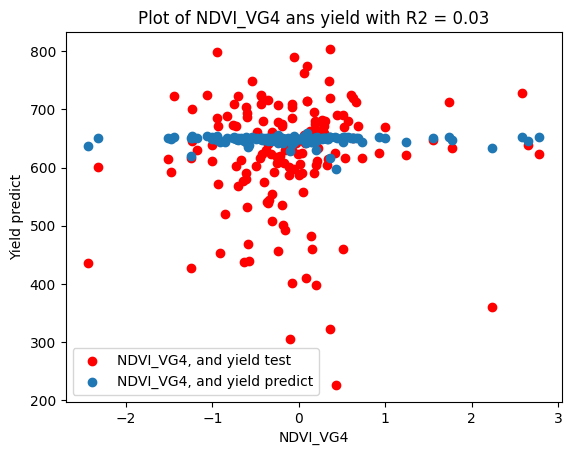

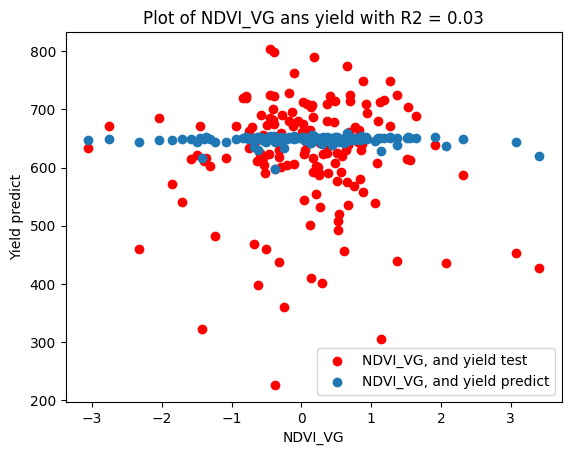

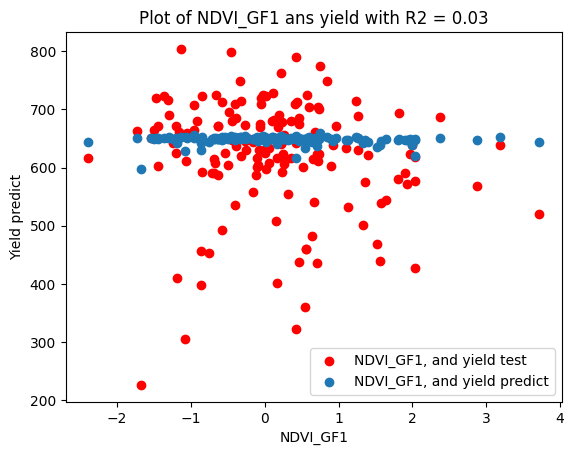

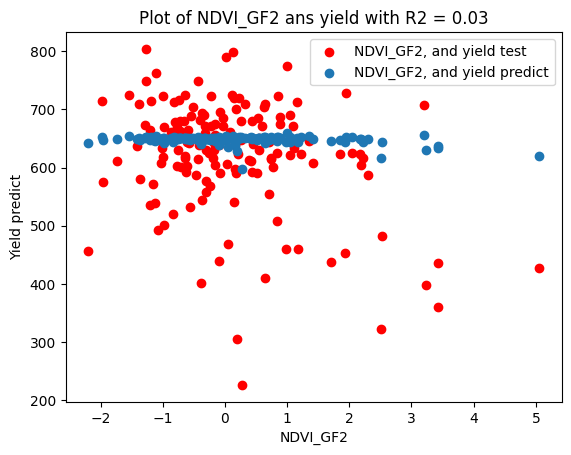

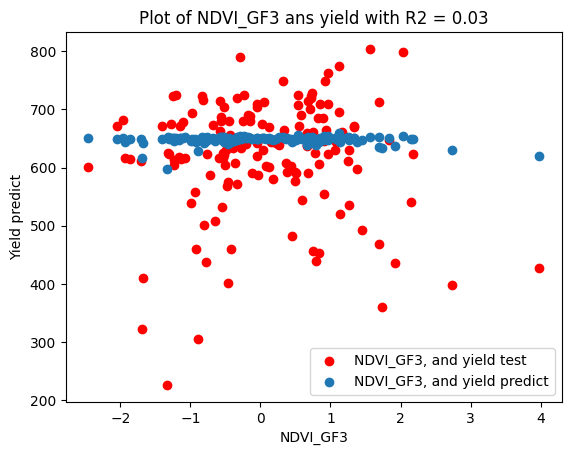

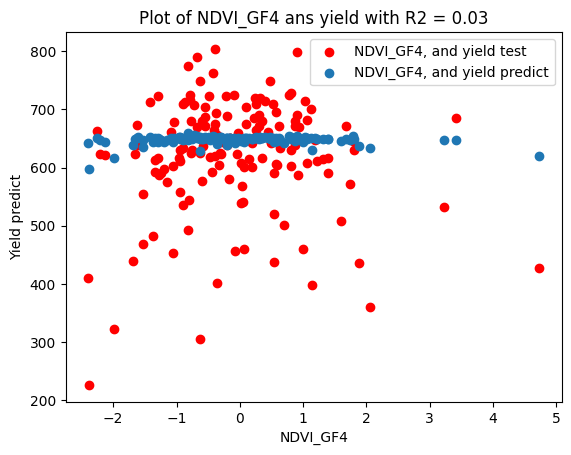

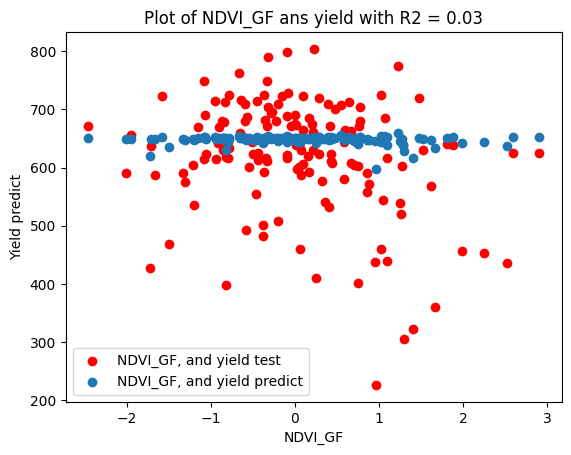

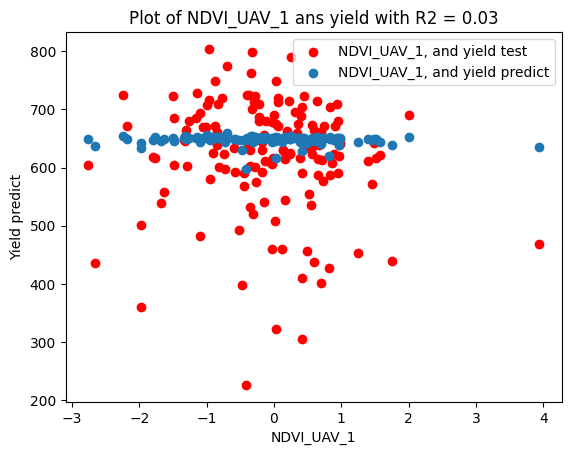

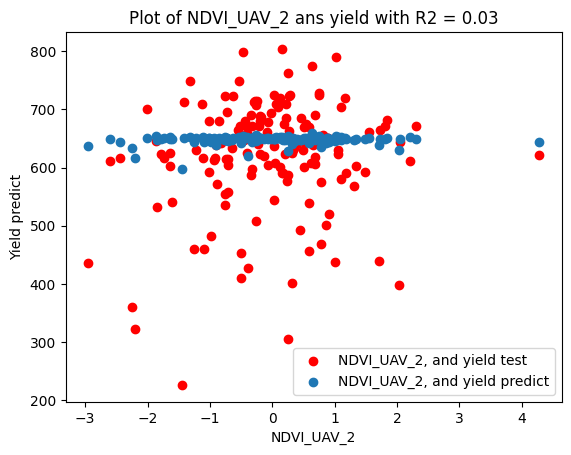

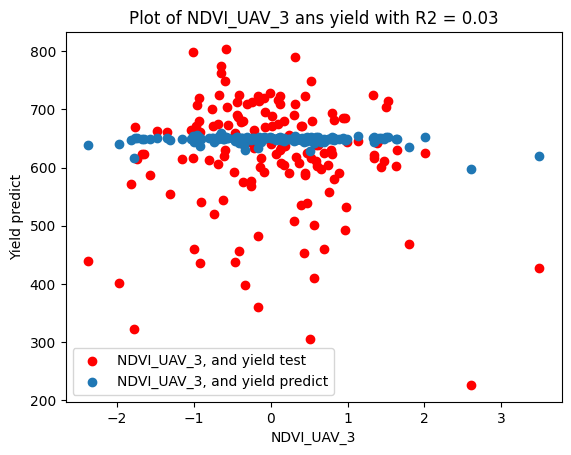

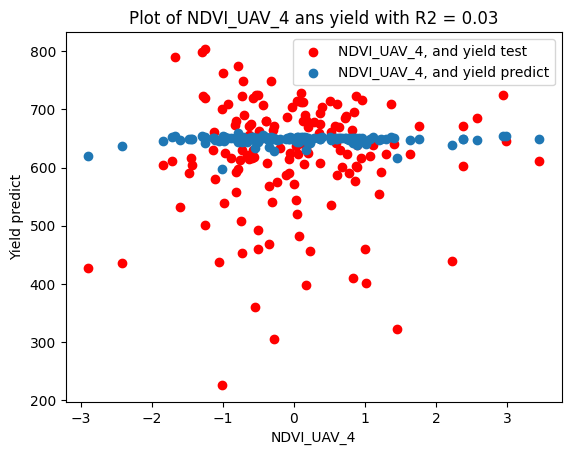

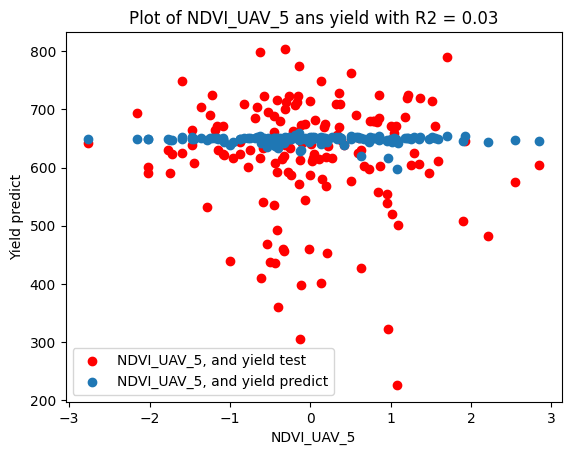

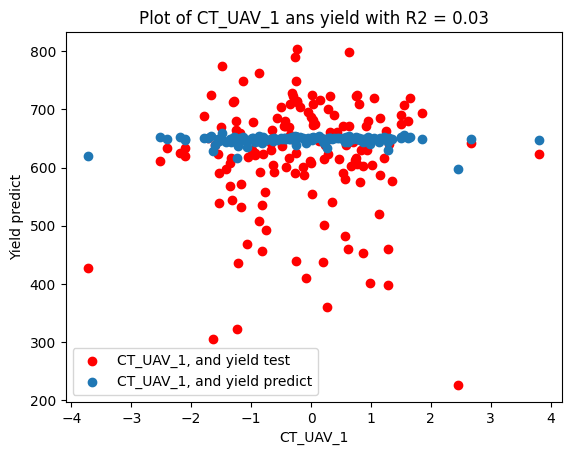

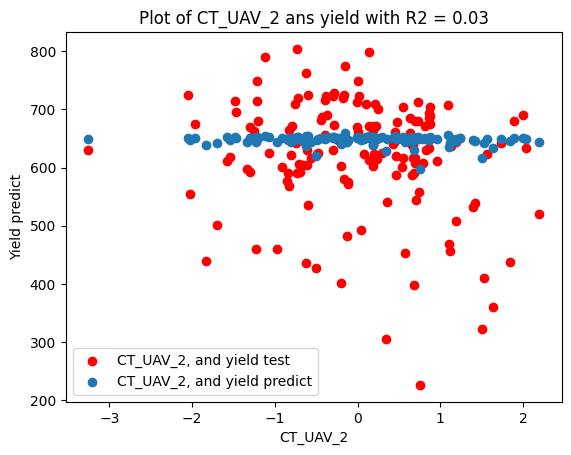

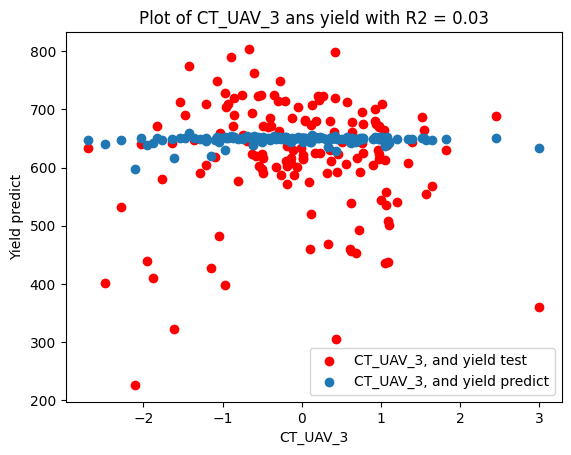

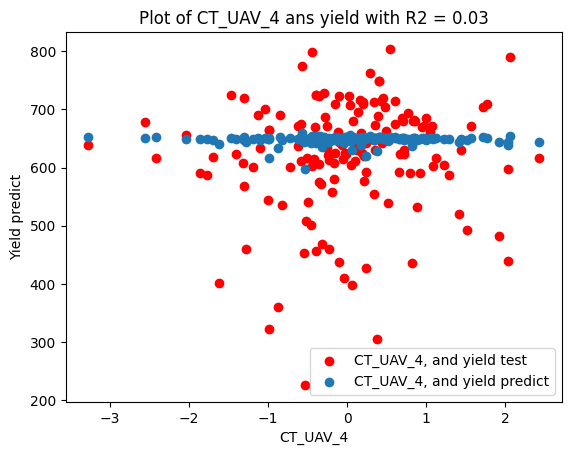

In [9]:
legend = PlotLegends()
legend.first_plot_label = "{variable}, and yield test"
legend.second_plot_label = "{variable}, and yield predict"
legend.title = "Plot of {variable} ans yield with R2 = {r2:.2f}"
legend.x_label = "{variable}"
legend.y_label = "Yield predict"
features = preprocessing.get_name_features()
metric.plot_r2_predicted(legend=legend, features=features)

Get the predict that are more bigger that .05

In [10]:
metric.list_percentage_error_upper(pivot=.04, sort = 'error')

[{'truth': 226.1118,
  'predict': 597.8458914970428,
  'error': 1.6440278282559457},
 {'truth': 304.5419,
  'predict': 628.1358632279421,
  'error': 1.0625597437592071},
 {'truth': 322.9881, 'predict': 616.844196059133, 'error': 0.909804714350569},
 {'truth': 360.0, 'predict': 634.3449082374594, 'error': 0.7620691895484984},
 {'truth': 400.8056,
  'predict': 640.9579619941483,
  'error': 0.5991741682105944},
 {'truth': 398.2896, 'predict': 629.593604954475, 'error': 0.5807432706113216},
 {'truth': 409.865, 'predict': 641.6424971979186, 'error': 0.5654971690627855},
 {'truth': 437.0, 'predict': 645.8252126558444, 'error': 0.4778608985259598},
 {'truth': 436.0, 'predict': 637.2778853103874, 'error': 0.4616465259412556},
 {'truth': 438.9351,
  'predict': 638.4400895475214,
  'error': 0.4545204736361286},
 {'truth': 427.0, 'predict': 619.781864580196, 'error': 0.45147977653441695},
 {'truth': 453.0, 'predict': 643.5345817403964, 'error': 0.4206061407072769},
 {'truth': 455.805, 'predict': 